In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")

# Understanding Dataset

In [2]:
df = pd.read_csv("train.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.shape

(891, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Handling Missing Values

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
df["Age"].fillna(df["Age"].median(), inplace = True)

# EDA

In [13]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

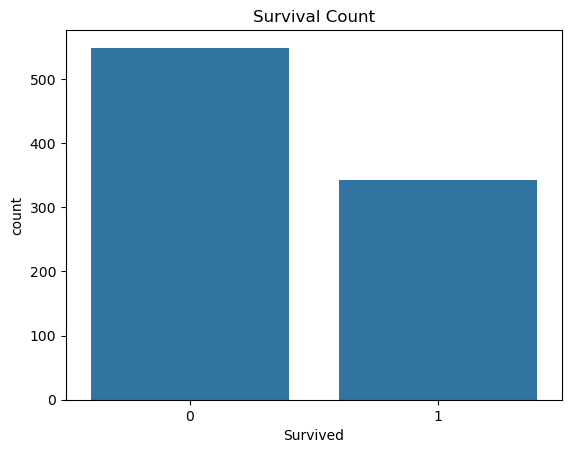

In [34]:
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

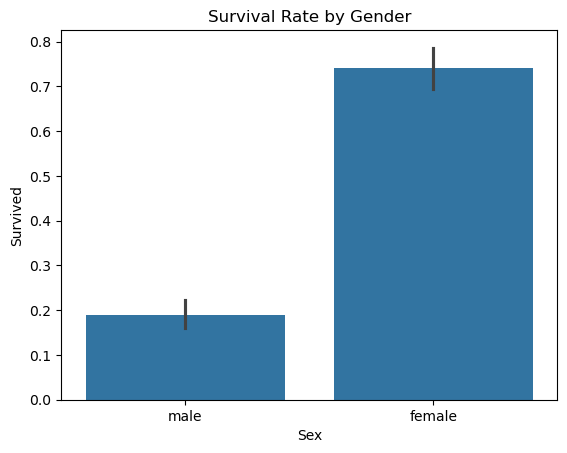

In [16]:
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Gender")
plt.show()

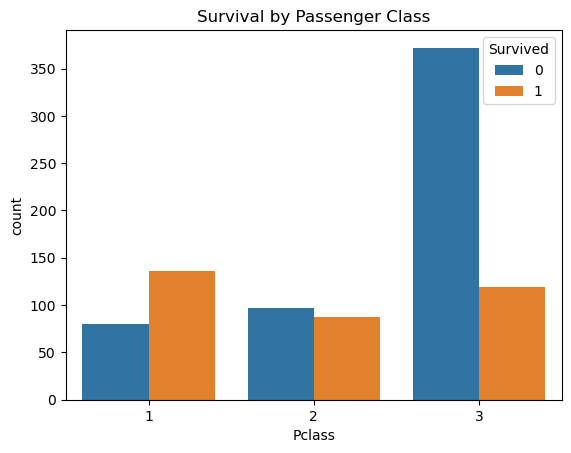

In [26]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

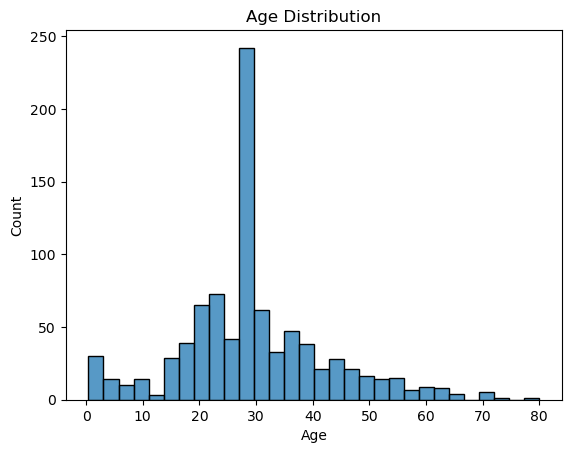

In [27]:
sns.histplot(df["Age"], bins=30)
plt.title("Age Distribution")
plt.show()

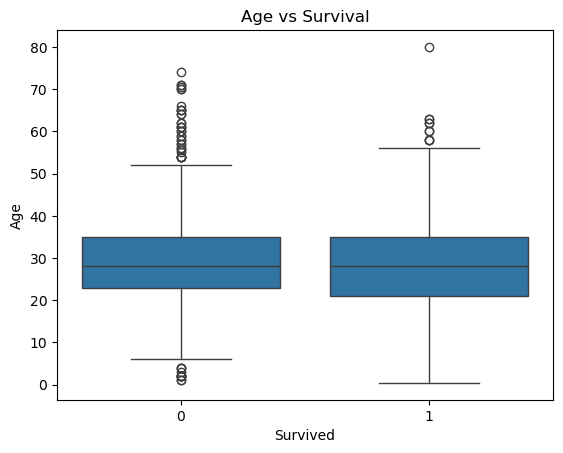

In [28]:
sns.boxplot(x="Survived", y="Age", data=df)
plt.title("Age vs Survival")
plt.show()

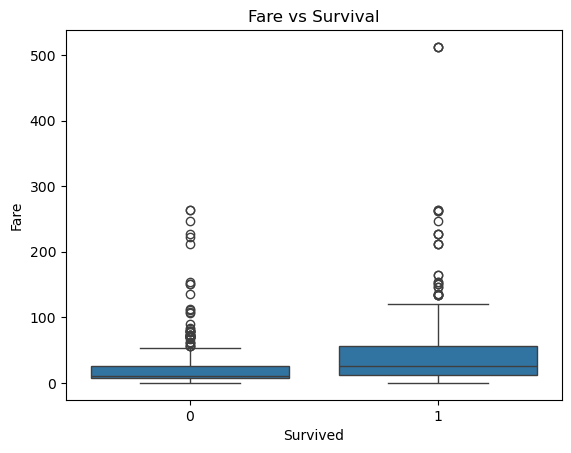

In [29]:
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Fare vs Survival")
plt.show()

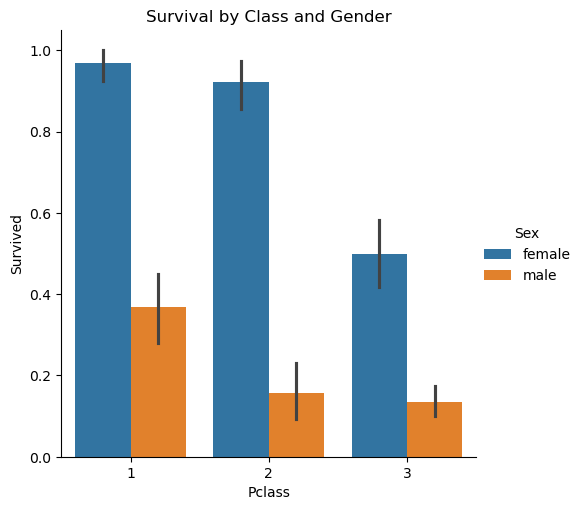

In [30]:
sns.catplot(x="Pclass", y="Survived", hue="Sex", kind="bar", data=df)
plt.title("Survival by Class and Gender")
plt.show()

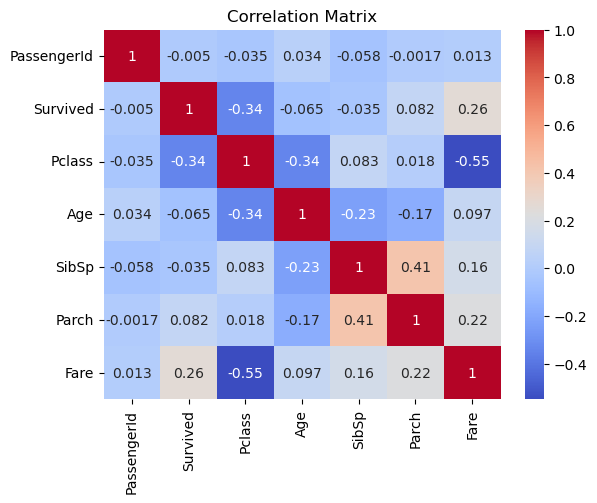

In [31]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

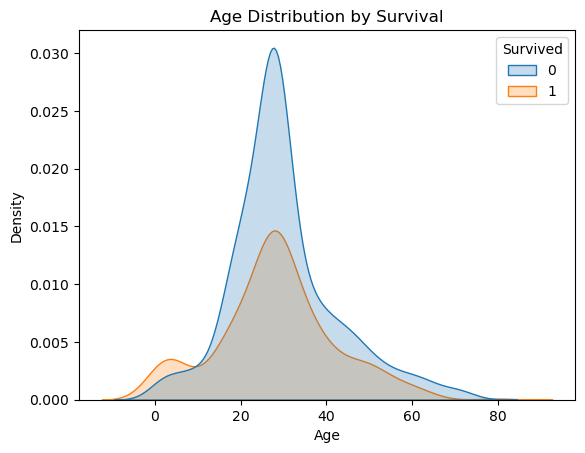

In [32]:
sns.kdeplot(data=df, x="Age", hue="Survived", fill=True)
plt.title("Age Distribution by Survival")
plt.show()

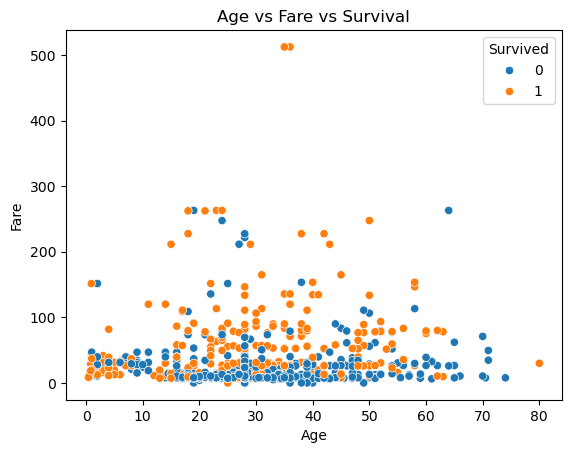

In [33]:
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df)
plt.title("Age vs Fare vs Survival")
plt.show()

# Key Insights

**1️ Women survived more than men**

Female passengers had a much higher survival rate compared to male passengers.

Reason:
During the evacuation, women and children were given priority for lifeboats.

**2️ First-class passengers had better survival chances**

Passengers in first class survived more often than those in second or third class.

Reason:
First-class passengers had better access to lifeboats and safer areas on the ship.

**3️ Third-class passengers had the lowest survival rate**

Most passengers in third class did not survive.

Reason:
They were located in lower decks, making evacuation slower and more difficult.

**4️ Higher ticket fare was linked to higher survival**

Passengers who paid higher ticket prices generally had a better survival rate.

Reason:
Higher fares usually meant higher passenger class, which had better survival chances.

**5️ Age had a small effect on survival**

Children had slightly better survival chances, but age was not as important as gender or class.

**6️ Women in first class had the highest survival rate**

Female passengers in first class had the best chance of survival.

This group had very high survival percentages.


**Conclusion:**

The analysis shows that gender and passenger class were the most important factors affecting survival on the Titanic. Women and first-class passengers had significantly higher survival rates, while third-class passengers and men had much lower chances of survival.